<a href="https://colab.research.google.com/github/shruti-python/credit-card-fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload creditcard.csv


Saving creditcard.csv to creditcard.csv

First Five Rows
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458

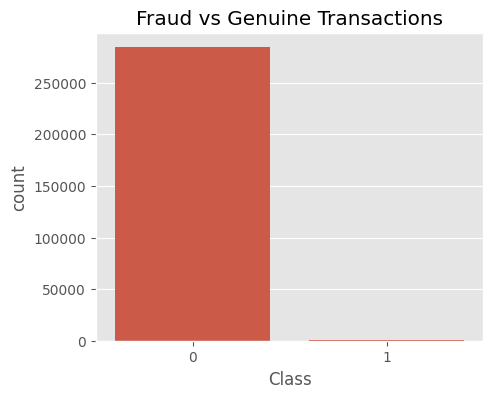

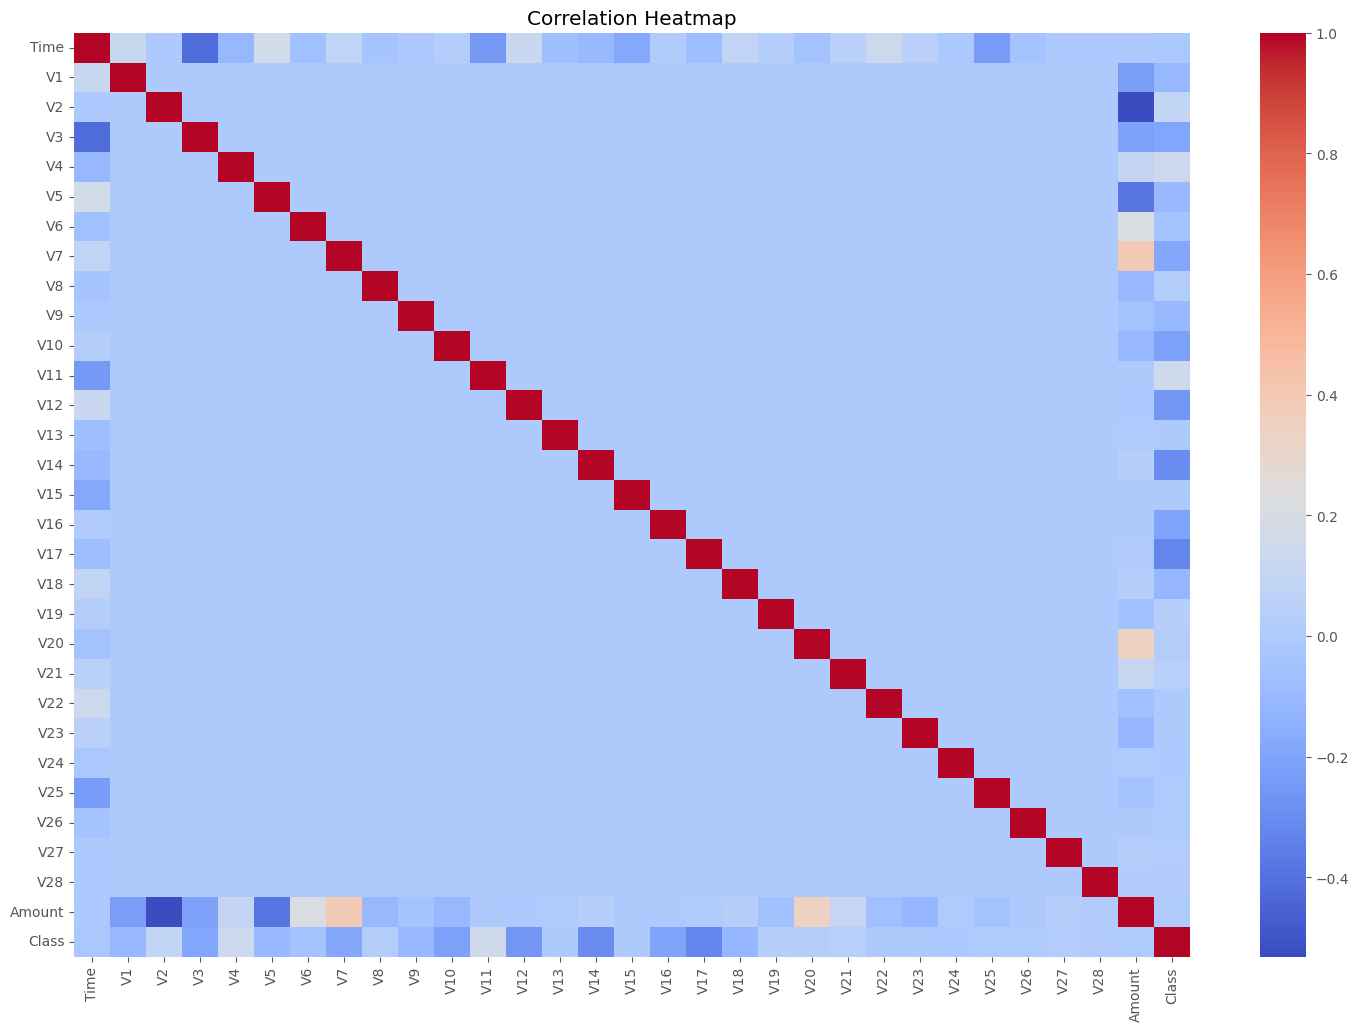


Training Shape: (227845, 30)
Testing Shape: (56962, 30)

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64

Training Logistic Regression...

========== Logistic Regression ==========
Accuracy : 0.9742635441171307
Precision: 0.05813953488372093
Recall   : 0.9183673469387755
F1 Score : 0.10935601458080195
ROC AUC  : 0.9463636115673055

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



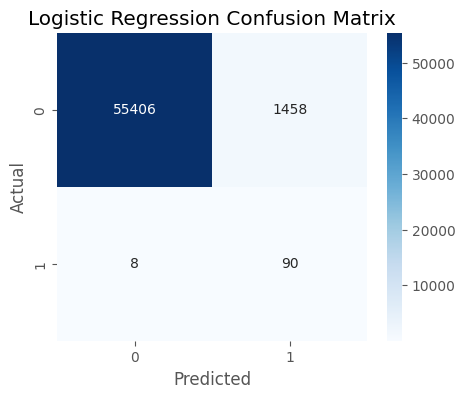

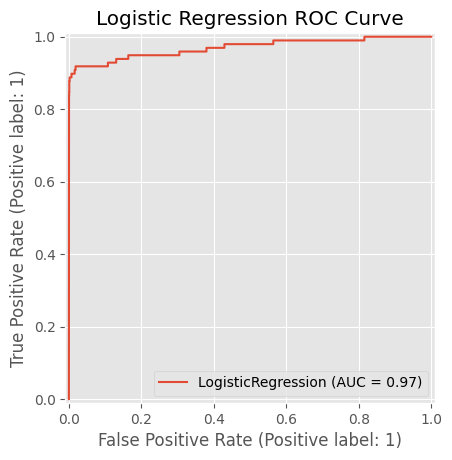


Training Random Forest...

========== Random Forest ==========
Accuracy : 0.9993504441557529
Precision: 0.8144329896907216
Recall   : 0.8061224489795918
F1 Score : 0.8102564102564103
ROC AUC  : 0.9029029521206345

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



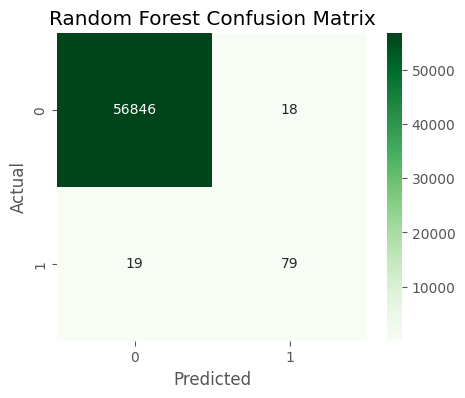

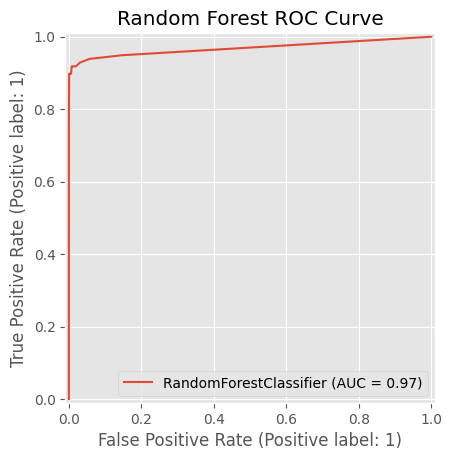


Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.974264   0.058140  0.918367  0.109356
1        Random Forest  0.999350   0.814433  0.806122  0.810256


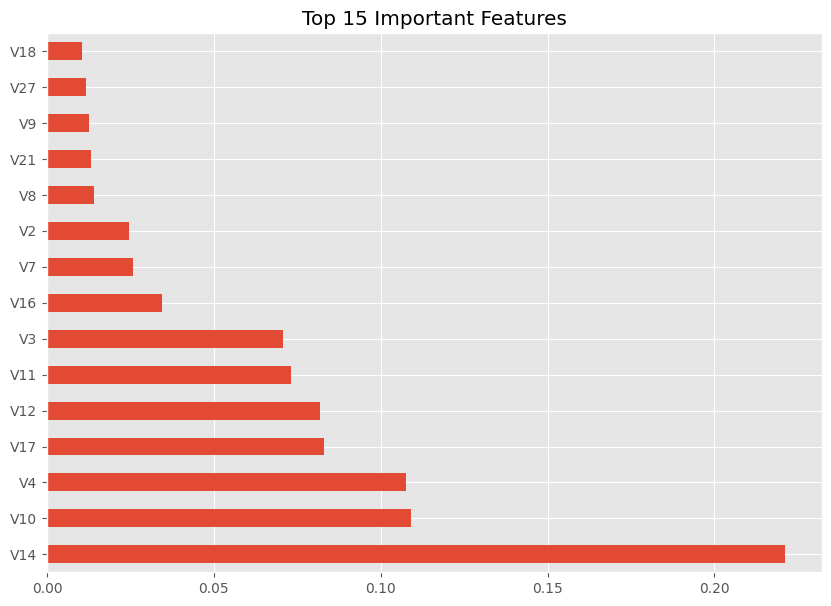


Model Saved Successfully
Saved Model Loaded

Prediction Result
✅ Genuine Transaction
Actual Class: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Project Completed Successfully!


In [1]:
-# ============================================================
# CREDIT CARD FRAUD DETECTION
# Complete Google Colab Project
# ============================================================

# Install Required Library
!pip install -q imbalanced-learn

# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

plt.style.use("ggplot")

# ============================================================
# Upload Dataset
# ============================================================

print("Upload creditcard.csv")
uploaded = files.upload()

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("/content/creditcard.csv")

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ============================================================
# Missing Values
# ============================================================

print("\nMissing Values")
print(df.isnull().sum())

# ============================================================
# Class Distribution
# ============================================================

print("\nClass Distribution")
print(df["Class"].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
df["scaled_time"] = scaler.fit_transform(df[["Time"]])

df.drop(["Amount","Time"], axis=1, inplace=True)

# ============================================================
# Feature and Target
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================================
# Apply SMOTE
# ============================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

# ============================================================
# Logistic Regression
# ============================================================

print("\nTraining Logistic Regression...")

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)

print("\n========== Logistic Regression ==========")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

# ============================================================
# Random Forest
# ============================================================

print("\nTraining Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            cmap="Greens",
            fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

# ============================================================
# Compare Models
# ============================================================

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

print("\nModel Comparison")
print(results)

# ============================================================
# Feature Importance
# ============================================================

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,7))
importance.head(15).plot(kind="barh")
plt.title("Top 15 Important Features")
plt.show()

# ============================================================
# Save Model
# ============================================================

joblib.dump(rf, "credit_card_fraud_model.pkl")

print("\nModel Saved Successfully")

# ============================================================
# Load Model
# ============================================================

model = joblib.load("credit_card_fraud_model.pkl")

print("Saved Model Loaded")

# ============================================================
# Prediction
# ============================================================

sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("\nPrediction Result")

if prediction[0] == 0:
    print("✅ Genuine Transaction")
else:
    print("🚨 Fraud Transaction")

print("Actual Class:", y_test.iloc[0])

# ============================================================
# Download Model
# ============================================================

files.download("credit_card_fraud_model.pkl")

print("\nProject Completed Successfully!")